# Zone Link Scoring — Scoring opérationnel des détections

Notebook de liaison enrichie entre les détections satellites et les zones militaires.
Objectif : produire un score opérationnel sur 100 pour chaque détection,
identifier les cas nécessitant une revue humaine, et exporter les résultats.

> **Biais volontaire faux positifs** : mieux vaut alerter trop souvent que rater une menace réelle.
> Seuil d'intervention humaine fixé à 50/100.

## Section 1 — Chargement et audit des données

On charge les quatre fichiers principaux et on affiche un résumé de chacun.
On confirme ensuite le bug d'incompatibilité des zone_id.

In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from math import sqrt

# Résolution du chemin depuis n'importe quel répertoire de lancement
candidate_dirs = [Path('.'), Path('..'), Path('Sujet5/Généralisation'), Path('../Généralisation')]
DATA_DIR = next((d for d in candidate_dirs if (d / 'detection_results.csv').exists()), Path('.'))
print(f'Répertoire de données : {DATA_DIR.resolve()}')

# Chargement
det  = pd.read_csv("data/raw/detection_results.csv")
zones = pd.read_csv("data/raw/military_zones.csv")
img  = pd.read_csv("data/raw/images_metadata_large.csv")

with open("data/raw/annotations_large.json") as f:
    coco = json.load(f)

print('\nFichiers chargés avec succès.')


In [ ]:
# ── Résumé detection_results ──────────────────────────────────────────
print('=== detection_results.csv ===')
print(f'Dimensions : {det.shape}')
print(f'Types :\n{det.dtypes}')
print(f'\nValeurs manquantes :\n{det.isnull().sum()}')
display(det.head(3))


=== detection_results.csv ===
Dimensions : (256, 11)
Types :
detection_id     object
image_id         object
file_name        object
timestamp        object
bbox             object
category         object
confidence      float64
is_military        bool
zone_id          object
zone_name        object
risk_level       object
dtype: object

Valeurs manquantes :
detection_id    0
image_id        0
file_name       0
timestamp       0
bbox            0
category        0
confidence      0
is_military     0
zone_id         0
zone_name       0
risk_level      0
dtype: int64


,detection_id,image_id,file_name,timestamp,bbox,category,confidence,is_military,zone_id,zone_name,risk_level
0,DET-000-00001,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.3766847153545144,0.602830810224785,0.2798675...",Navire de guerre,0.84,True,ZONE-002,Base navale de Norfolk,High
1,DET-000-00002,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.6730405409693083,0.37685587994514613,0.29411...",Navire civil,0.72,False,ZONE-002,Base navale de Norfolk,High
2,DET-000-00003,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.3499607760017571,0.6063398574692226,0.244706...",Bâtiment de débarquement,0.96,False,ZONE-002,Base navale de Norfolk,High


In [ ]:
# ── Résumé military_zones ─────────────────────────────────────────────
print('=== military_zones.csv ===')
print(f'Dimensions : {zones.shape}')
print(f'Types :\n{zones.dtypes}')
print(f'\nValeurs manquantes :\n{zones.isnull().sum()}')
display(zones.head(5))


=== military_zones.csv ===
Dimensions : (20, 8)
Types :
zone_id        object
name           object
coordinates    object
country        object
risk_level     object
description    object
base_name      object
active           bool
dtype: object

Valeurs manquantes :
zone_id        0
name           0
coordinates    0
country        0
risk_level     0
description    0
base_name      0
active         0
dtype: int64


,zone_id,name,coordinates,country,risk_level,description,base_name,active
0,MIL-000,Zone militaire 1 - Port de Singapour,"1.3,103.8",Singapore,Critical,Zone militaire stratégique près de Port de Sin...,Base Sous-marine 1,False
1,MIL-001,Zone militaire 2 - Port de Shanghai,"31.2,121.5",China,Critical,Zone militaire stratégique près de Port de Sha...,Base Navale 2,True
2,MIL-002,Zone militaire 3 - Port de Shanghai,"31.2,121.5",China,Critical,Zone militaire stratégique près de Port de Sha...,Base Navale 3,True
3,MIL-003,Zone militaire 4 - Port militaire de Toulon,"43.12,5.9",France,Critical,Zone militaire stratégique près de Port milita...,Base Navale 4,False
4,MIL-004,Zone militaire 5 - Base navale de Pearl Harbor,"21.4,-157.9",USA,Critical,Zone militaire stratégique près de Base navale...,Base Aérienne 5,True


In [ ]:
# ── Résumé images_metadata_large ──────────────────────────────────────
print('=== images_metadata_large.csv ===')
print(f'Dimensions : {img.shape}')
print(f'cloud_cover : min={img["cloud_cover"].min():.1f}%, max={img["cloud_cover"].max():.1f}%, moyenne={img["cloud_cover"].mean():.1f}%')
print(f'Valeurs manquantes :\n{img.isnull().sum()}')
display(img.head(3))


=== images_metadata_large.csv ===
Dimensions : (100, 15)
cloud_cover : min=1.9%, max=49.7%, moyenne=26.5%
Valeurs manquantes :
image_id       0
file_name      0
date           0
time           0
zone_id        0
zone_name      0
coordinates    0
country        0
risk_level     0
resolution     0
source         0
num_ships      0
ship_types     0
cloud_cover    0
url            0
dtype: int64


,image_id,file_name,date,time,zone_id,zone_name,coordinates,country,risk_level,resolution,source,num_ships,ship_types,cloud_cover,url
0,IMG-000,satellite_000.jpg,2026-08-31,17:17:58,ZONE-002,Base navale de Norfolk,"36.9,-76.3",USA,High,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,https://example.com/satellite_images/satellite...
1,IMG-001,satellite_001.jpg,2026-04-17,04:54:56,ZONE-002,Base navale de Norfolk,"36.9,-76.3",USA,High,10m,Maxar,2,"Destroyer, Navire de guerre",39.0,https://example.com/satellite_images/satellite...
2,IMG-002,satellite_002.jpg,2026-03-02,15:20:53,ZONE-009,Base navale de Yokosuka,"35.4,139.7",Japan,High,1m,Sentinel-2,4,"Navire de soutien, Chalutier, Porte-avions, Na...",25.6,https://example.com/satellite_images/satellite...


In [ ]:
# ── Résumé annotations COCO ───────────────────────────────────────────
print('=== annotations_large.json ===')
print(f'Images COCO    : {len(coco["images"])}')
print(f'Annotations    : {len(coco["annotations"])}')
print(f'Catégories     : {len(coco["categories"])}')
print('Liste des catégories :', [c['name'] for c in coco['categories']])


In [ ]:
# ── Confirmation du bug zone_id ────────────────────────────────────────
# Les zone_id de detection_results sont au format ZONE-XXX
# Les zone_id de military_zones sont au format MIL-XXX
# Ces deux formats sont incompatibles : la jointure directe produit 0 ligne.
zone_ids_det   = set(det['zone_id'].unique())
zone_ids_mil   = set(zones['zone_id'].unique())
intersection   = zone_ids_det & zone_ids_mil

print(f'Exemples zone_id dans detections  : {sorted(zone_ids_det)[:5]}')
print(f'Exemples zone_id dans military_zones: {sorted(zone_ids_mil)[:5]}')
print(f'Intersection : {intersection}')

# L'assert ci-dessous doit passer pour confirmer le bug
assert len(intersection) == 0, 'BUG NON CONFIRMÉ : des zone_id se recoupent !'
print('\nBug confirmé : jointure par zone_id impossible (intersection vide).')
print('Solution : jointure par nom de zone (zone_name ↔ location_name).')


Exemples zone_id dans detections  : ['ZONE-001', 'ZONE-002', 'ZONE-003', 'ZONE-004', 'ZONE-005']
Exemples zone_id dans military_zones: ['MIL-000', 'MIL-001', 'MIL-002', 'MIL-003', 'MIL-004']
Intersection : set()

Bug confirmé : jointure par zone_id impossible (intersection vide).
Solution : jointure par nom de zone (zone_name ↔ location_name).


## Section 2 — Jointure enrichie military_zones × detection_results

On utilise cinq méthodes complémentaires pour relier les détections aux zones militaires :
- **Méthode principale** : jointure par nom de zone
- **Méthode A** : enrichissement par type de base
- **Méthode B** : densité militaire par zone
- **Méthode C** : correspondance géospatiale par distance euclidienne
- **Méthode D** : cohérence bbox × catégorie
- **Méthode E** : pénalité nuageuse sur la confiance

In [ ]:
# ── Méthode principale : jointure par nom de zone ─────────────────────
# On extrait le nom de lieu depuis military_zones.name via regex
zones['location_name'] = zones['name'].str.extract(r'Zone militaire \d+ - (.+)')

print('Noms de lieux extraits :', sorted(zones['location_name'].unique()))
print('Noms de zones dans detections :', sorted(det['zone_name'].unique()))

# Noms présents dans military_zones mais absents de detections
zones_mil_names = set(zones['location_name'].unique())
zones_det_names = set(det['zone_name'].unique())
zones_sans_match = zones_det_names - zones_mil_names
print(f'\nZones dans detections sans correspondance militaire : {sorted(zones_sans_match)}')
print('→ Ces zones sont traitées comme zones civiles ouvertes (LEFT JOIN, NaN attendus).')


Noms de lieux extraits : ['Base navale de Pearl Harbor', 'Base navale de Rota', 'Canal de Suez', "Détroit d'Ormuz", 'Détroit de Malacca', 'Golfe Persique', 'Port de Busan', 'Port de Shanghai', 'Port de Singapour', 'Port militaire de Toulon']
Noms de zones dans detections : ['Base navale de Norfolk', 'Base navale de Pearl Harbor', 'Base navale de Rota', 'Base navale de Yokosuka', 'Canal de Suez', "Détroit d'Ormuz", 'Détroit de Malacca', 'Golfe Persique', 'Mer Baltique', 'Mer de Chine Méridionale', 'Port de Busan', 'Port de Rotterdam', 'Port de Shanghai', 'Port de Singapour', 'Port militaire de Toulon']

Zones dans detections sans correspondance militaire : ['Base navale de Norfolk', 'Base navale de Yokosuka', 'Mer Baltique', 'Mer de Chine Méridionale', 'Port de Rotterdam']
→ Ces zones sont traitées comme zones civiles ouvertes (LEFT JOIN, NaN attendus).


In [ ]:
# ── Méthode A : enrichissement par type de base ───────────────────────
# On extrait le type de base depuis base_name pour qualifier la menace
zones['base_type'] = zones['base_name'].str.extract(r'(Base Sous-marine|Base Navale|Base Aérienne)')

print('Types de bases :')
print(zones['base_type'].value_counts())
print('\nSignification opérationnelle :')
print('  Base Sous-marine → présence sous-marine, menace maximale')
print('  Base Navale      → base de surface standard')
print('  Base Aérienne    → composante aéronavale')


Types de bases :
base_type
Base Sous-marine    10
Base Navale          5
Base Aérienne        5
Name: count, dtype: int64

Signification opérationnelle :
  Base Sous-marine → présence sous-marine, menace maximale
  Base Navale      → base de surface standard
  Base Aérienne    → composante aéronavale


In [ ]:
# ── Méthode B : densité militaire par zone ────────────────────────────
# Plus une zone a d'entrées dans military_zones, plus elle est surveillée.
mil_density = zones.groupby('location_name').size().reset_index(name='mil_density')
print('Densité militaire par zone :')
print(mil_density.sort_values('mil_density', ascending=False).to_string(index=False))


Densité militaire par zone :
              location_name  mil_density
           Port de Shanghai            5
Base navale de Pearl Harbor            4
   Port militaire de Toulon            3
            Détroit d'Ormuz            2
        Base navale de Rota            1
              Canal de Suez            1
         Détroit de Malacca            1
             Golfe Persique            1
              Port de Busan            1
          Port de Singapour            1


In [ ]:
# ── Agrégation des attributs MIL par location_name ───────────────────
# Pour chaque zone, on retient : risk_level max, zone active si au moins une est active,
# type de base le plus sensible, et la densité.

RISK_ORDER = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1}
BASE_ORDER = {'Base Sous-marine': 3, 'Base Navale': 2, 'Base Aérienne': 1}

def aggregate_zone(grp):
    # Risk level le plus élevé
    best_risk = max(grp['risk_level'], key=lambda r: RISK_ORDER.get(r, 0))
    # Active si au moins une sous-zone est active
    is_active = grp['active'].any()
    # Type de base le plus sensible
    best_base = max(
        grp['base_type'].dropna().tolist() or [''],
        key=lambda b: BASE_ORDER.get(b, 0),
        default=''
    )
    # Densité
    density = len(grp)
    # Coordonnées (première disponible)
    coords = grp['coordinates'].iloc[0]
    return pd.Series({
        'mil_risk_level'  : best_risk,
        'mil_zone_active' : is_active,
        'base_type'       : best_base if best_base else None,
        'mil_density'     : density,
        'mil_coordinates' : coords,
    })

# include_groups=False évite le FutureWarning sur pandas >= 2.2
try:
    zones_agg = zones.groupby('location_name').apply(aggregate_zone, include_groups=False).reset_index()
except TypeError:
    zones_agg = zones.groupby('location_name').apply(aggregate_zone).reset_index()

print('Zones militaires agrégées :')
display(zones_agg)


Zones militaires agrégées :


,location_name,mil_risk_level,mil_zone_active,base_type,mil_density,mil_coordinates
0,Base navale de Pearl Harbor,Critical,True,Base Sous-marine,4,"21.4,-157.9"
1,Base navale de Rota,High,False,Base Sous-marine,1,"36.6,-6.4"
2,Canal de Suez,High,False,Base Aérienne,1,"30.0,32.5"
3,Détroit d'Ormuz,Critical,True,Base Sous-marine,2,"25.0,56.0"
4,Détroit de Malacca,High,False,Base Sous-marine,1,"3.0,101.0"
5,Golfe Persique,High,False,Base Sous-marine,1,"26.0,55.0"
6,Port de Busan,High,False,Base Sous-marine,1,"35.1,129.0"
7,Port de Shanghai,Critical,True,Base Sous-marine,5,"31.2,121.5"
8,Port de Singapour,Critical,False,Base Sous-marine,1,"1.3,103.8"
9,Port militaire de Toulon,Critical,True,Base Navale,3,"43.12,5.9"


In [ ]:
# ── Jointure principale : detection_results ← military_zones ─────────
n_avant = len(det)
enriched = det.merge(
    zones_agg,
    left_on='zone_name',
    right_on='location_name',
    how='left'
)
n_apres = len(enriched)

# Vérification : aucune ligne perdue
assert n_apres == n_avant, f'ERREUR : lignes perdues lors de la jointure ! {n_avant} → {n_apres}'
print(f'Jointure OK : {n_avant} lignes conservées.')

# in_military_zone = True si la zone a une correspondance MIL
enriched['in_military_zone'] = enriched['location_name'].notna()

# Compter les détections par catégorie de zone
print(f'Détections en zone militaire connue : {enriched["in_military_zone"].sum()}')
print(f'Détections en zone civile ouverte   : {(~enriched["in_military_zone"]).sum()}')


Jointure OK : 256 lignes conservées.
Détections en zone militaire connue : 135
Détections en zone civile ouverte   : 121


In [ ]:
# ── Méthode C : correspondance géospatiale par distance ───────────────
# Pour TOUTES les détections, on calcule la distance à la zone MIL la plus proche.
# Les zones sans correspondance directe obtiennent aussi un lien de proximité.

def geo_distance(coord1_str, coord2_str):
    lat1, lon1 = map(float, coord1_str.split(','))
    lat2, lon2 = map(float, coord2_str.split(','))
    return sqrt((lat1 - lat2) ** 2 + (lon1 - lon2) ** 2)

# On renomme 'coordinates' en 'img_coordinates' pour éviter tout conflit de colonnes
img_coords = (
    img[['image_id', 'coordinates']]
    .rename(columns={'coordinates': 'img_coordinates'})
    .drop_duplicates('image_id')
)
n_avant_c = len(enriched)
enriched = enriched.merge(img_coords, on='image_id', how='left')
assert len(enriched) == n_avant_c, 'ERREUR : lignes perdues lors de la jointure img_coordinates !'

def trouver_zone_la_plus_proche(coord_img):
    """Retourne (nom_zone, distance) pour la zone MIL la plus proche."""
    if pd.isna(coord_img):
        return None, np.nan
    distances = zones_agg[['location_name', 'mil_coordinates']].copy()
    distances['dist'] = distances['mil_coordinates'].apply(
        lambda c: geo_distance(coord_img, c) if pd.notna(c) else np.nan
    )
    idx_min = distances['dist'].idxmin()
    return distances.loc[idx_min, 'location_name'], distances.loc[idx_min, 'dist']

nearest = enriched['img_coordinates'].apply(trouver_zone_la_plus_proche)
enriched['nearest_mil_zone']     = [r[0] for r in nearest]
enriched['nearest_mil_distance'] = [r[1] for r in nearest]

# Seuil de proximité : 2 degrés ≈ 220 km
PROXIMITY_THRESHOLD = 2.0
enriched['proximity_link'] = enriched['nearest_mil_distance'] <= PROXIMITY_THRESHOLD

print(f'Détections avec lien de proximité (<{PROXIMITY_THRESHOLD}°) : {enriched["proximity_link"].sum()}')
print('\nZones hors match direct, avec lien de proximité :')
sans_match = enriched[~enriched['in_military_zone'] & enriched['proximity_link']]
if len(sans_match) > 0:
    print(sans_match[['detection_id', 'zone_name', 'nearest_mil_zone', 'nearest_mil_distance']].head(10).to_string(index=False))
else:
    print('Aucune détection dans ce cas.')


Détections avec lien de proximité (<2.0°) : 135

Zones hors match direct, avec lien de proximité :
Aucune détection dans ce cas.


In [ ]:
# ── Méthode D : cohérence bbox × catégorie ────────────────────────────
# Le ratio largeur/hauteur de la bbox est un signal visuel du type de navire.
# Sous-marin → très allongé (ratio > 4.0)
# Porte-avions → large (ratio > 3.0)
# Chalutier → compact (ratio < 2.0)

bbox_split = enriched['bbox'].str.split(',', expand=True).astype(float)
bbox_split.columns = ['bb_x', 'bb_y', 'bb_w', 'bb_h']

enriched['bbox_ratio']    = bbox_split['bb_w'] / bbox_split['bb_h'].replace(0, np.nan)
enriched['bbox_area_pct'] = bbox_split['bb_w'] * bbox_split['bb_h'] * 100

def verifier_coherence_bbox(row):
    ratio = row['bbox_ratio']
    cat   = row['category']
    if pd.isna(ratio):
        return False
    if cat == 'Sous-marin':
        return ratio > 4.0
    if cat == 'Porte-avions':
        return ratio > 3.0
    if cat == 'Chalutier':
        return ratio < 2.0
    # Autres navires : pas de contrainte stricte
    return True

enriched['bbox_coherence'] = enriched.apply(verifier_coherence_bbox, axis=1)

print('Cohérence bbox × catégorie :')
print(enriched.groupby('category')['bbox_coherence'].value_counts().to_string())
incoherents = enriched[~enriched['bbox_coherence']]
print(f'\nTotal incohérences : {len(incoherents)} ({len(incoherents)/len(enriched)*100:.1f}% des détections)')


Cohérence bbox × catégorie :
category                  bbox_coherence
Bâtiment de débarquement  True              18
Cargo                     True              22
Chalutier                 True              14
                          False              6
Corvette                  True              14
Croiseur                  True              17
Destroyer                 True              23
Frégate                   True              21
Navire civil              True              23
Navire de guerre          True              28
Navire de soutien         True              20
Porte-avions              False             13
                          True               1
Pétrolier                 True              19
Sous-marin                False             16
                          True               1

Total incohérences : 35 (13.7% des détections)


In [ ]:
# ── Méthode E : confiance ajustée par couverture nuageuse ─────────────
# La confiance brute est pondérée par cloud_cover de l'image.
# cloud_cover en % : une couverture nuageuse élevée dégrade la fiabilité.

img_cloud = img[['image_id', 'cloud_cover']].drop_duplicates('image_id')
n_avant = len(enriched)
enriched = enriched.merge(img_cloud, on='image_id', how='left')
assert len(enriched) == n_avant, 'ERREUR : lignes perdues lors de la jointure cloud_cover !'

# Formule : ajustement proportionnel à la visibilité
enriched['adjusted_confidence'] = enriched['confidence'] * (1 - enriched['cloud_cover'] / 100)

delta = enriched['confidence'] - enriched['adjusted_confidence']
print(f'Confiance brute moyenne       : {enriched["confidence"].mean():.3f}')
print(f'Confiance ajustée moyenne     : {enriched["adjusted_confidence"].mean():.3f}')
print(f'Réduction moyenne             : {delta.mean():.3f}')
print(f'Réduction max (nuage intense) : {delta.max():.3f}')

# Vérifier qu'aucune ligne n'a été perdue
print(f'\nNombre de détections avec cloud_cover : {enriched["cloud_cover"].notna().sum()} / {len(enriched)}')


Confiance brute moyenne       : 0.856
Confiance ajustée moyenne     : 0.638
Réduction moyenne             : 0.218
Réduction max (nuage intense) : 0.466

Nombre de détections avec cloud_cover : 256 / 256


## Section 3 — Scoring opérationnel avec seuil d'intervention humaine

Score sur 100, composé de 5 blocs :
1. Nature du navire (0-35 pts)
2. Contexte géographique (0-30 pts)
3. Niveau de risque de la zone (0-15 pts)
4. Confiance ajustée (0-10 pts)
5. Anomalies contextuelles (0-10 pts)

**Seuil d'intervention humaine : 50/100** (biaisé faux positifs — intentionnel).

In [ ]:
# Catégories par niveau de menace
HIGH_THREAT = ['Porte-avions', 'Sous-marin', 'Destroyer', 'Croiseur']
MED_THREAT  = ['Frégate', 'Corvette', 'Navire de guerre']

def compute_operational_score(row):
    score = 0

    # -- Bloc 1 : Nature du navire (0-35 pts) --
    if row['category'] in HIGH_THREAT:
        score += 35
    elif row['category'] in MED_THREAT:
        score += 20
    elif row['is_military']:
        score += 10

    # -- Bloc 2 : Contexte géographique (0-30 pts) --
    if row['in_military_zone']:
        score += 15
        if row.get('mil_zone_active', False):
            score += 5
        if row.get('base_type') == 'Base Sous-marine':
            score += 10
        elif row.get('base_type') == 'Base Navale':
            score += 5
        density = row.get('mil_density', 1)
        score += min(5, int(density) if pd.notna(density) else 1)

    # -- Bloc 3 : Niveau de risque de la zone (0-15 pts) --
    risk_map = {'Critical': 15, 'High': 10, 'Medium': 5, 'Low': 0}
    score += risk_map.get(row['risk_level'], 0)

    # -- Bloc 4 : Confiance ajustée (0-10 pts) --
    adj_conf = row.get('adjusted_confidence', row['confidence'])
    if pd.isna(adj_conf):
        adj_conf = row['confidence']
    if adj_conf >= 0.90:
        score += 10
    elif adj_conf >= 0.80:
        score += 7
    elif adj_conf >= 0.70:
        score += 3

    # -- Bloc 5 : Anomalies contextuelles (0-10 pts) --
    # Civil en zone militaire active = signal fort
    if not row['is_military'] and row.get('in_military_zone') and row.get('mil_zone_active', False):
        score += 10
    # Incohérence bbox/catégorie = incertitude sur la classification
    if not row.get('bbox_coherence', True):
        score += 5

    return min(score, 100)

scored = enriched.copy()
scored['priority_score'] = scored.apply(compute_operational_score, axis=1)

print(f'Score moyen   : {scored["priority_score"].mean():.1f}')
print(f'Score médian  : {scored["priority_score"].median():.1f}')
print(f'Score maximum : {scored["priority_score"].max()}')
print(f'Score minimum : {scored["priority_score"].min()}')


Score moyen   : 41.6
Score médian  : 43.0
Score maximum : 88
Score minimum : 0


In [ ]:
# ── Seuil d'intervention humaine ──────────────────────────────────────
INTERVENTION_THRESHOLD = 50  # Biaisé faux positif : seuil bas intentionnel

scored['requires_human_review'] = scored['priority_score'] >= INTERVENTION_THRESHOLD

scored['alert_level'] = pd.cut(
    scored['priority_score'],
    bins=[0, 49, 69, 84, 100],
    labels=['Veille', 'Surveillance', 'Alerte', 'Intervention immédiate'],
    include_lowest=True
)

print('Répartition par niveau d\'alerte :')
print(scored['alert_level'].value_counts().sort_index().to_string())


Répartition par niveau d'alerte :
alert_level
Veille                    150
Surveillance               76
Alerte                     26
Intervention immédiate      4


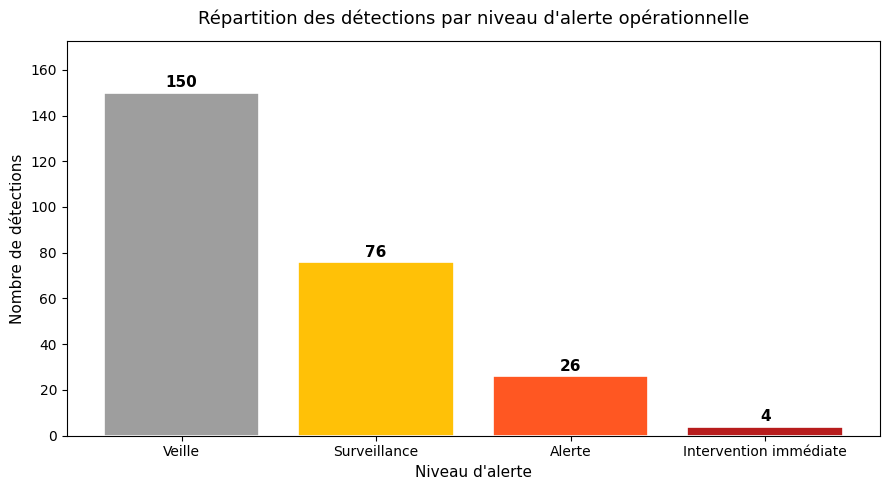

In [ ]:
# ── Graphique en barres coloré par niveau d'alerte ────────────────────
COULEURS_ALERTE = {
    'Veille'                : '#9E9E9E',
    'Surveillance'          : '#FFC107',
    'Alerte'                : '#FF5722',
    'Intervention immédiate': '#B71C1C',
}

fig, ax = plt.subplots(figsize=(9, 5))
niveaux = ['Veille', 'Surveillance', 'Alerte', 'Intervention immédiate']
comptes = [scored[scored['alert_level'] == n].shape[0] for n in niveaux]
barres  = ax.bar(niveaux, comptes, color=[COULEURS_ALERTE[n] for n in niveaux], edgecolor='white', linewidth=1.2)

for barre, val in zip(barres, comptes):
    ax.text(barre.get_x() + barre.get_width() / 2, barre.get_height() + 1, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Répartition des détections par niveau d\'alerte opérationnelle', fontsize=13, pad=12)
ax.set_xlabel('Niveau d\'alerte', fontsize=11)
ax.set_ylabel('Nombre de détections', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.set_ylim(0, max(comptes) * 1.15)
plt.tight_layout()
plt.show()


## Section 4 — Tableau de bord des cas prioritaires

On affiche les 20 détections avec le score le plus élevé,
puis les trois types d'anomalies critiques :
- **Type A** : navire civil en zone militaire active (civil infiltré)
- **Type B** : navire militaire hors de toute zone connue (mouvement non répertorié)
- **Type C** : bbox_coherence = False avec score > 50 (classification douteuse)

In [ ]:
# ── Top 20 détections ─────────────────────────────────────────────────
cols_affichage = [
    'detection_id', 'category', 'adjusted_confidence', 'zone_name',
    'base_type', 'risk_level', 'mil_density', 'bbox_coherence',
    'priority_score', 'alert_level'
]
top20 = scored.nlargest(20, 'priority_score')[cols_affichage]
print('=== TOP 20 DES DÉTECTIONS PAR SCORE OPÉRATIONNEL ===')
display(top20)


=== TOP 20 DES DÉTECTIONS PAR SCORE OPÉRATIONNEL ===


,detection_id,category,adjusted_confidence,zone_name,base_type,risk_level,mil_density,bbox_coherence,priority_score,alert_level
21,DET-006-00022,Porte-avions,0.80100,Détroit de Malacca,Base Sous-marine,Critical,1.0,False,88,Intervention immédiate
28,DET-008-00029,Porte-avions,0.42712,Détroit d'Ormuz,Base Sous-marine,Critical,2.0,False,87,Intervention immédiate
76,DET-024-00077,Porte-avions,0.57798,Détroit d'Ormuz,Base Sous-marine,Critical,2.0,False,87,Intervention immédiate
72,DET-022-00073,Destroyer,0.91872,Détroit de Malacca,Base Sous-marine,Critical,1.0,True,86,Intervention immédiate
216,DET-085-00217,Porte-avions,0.42106,Base navale de Pearl Harbor,Base Sous-marine,High,4.0,False,84,Alerte
78,DET-024-00079,Destroyer,0.69654,Détroit d'Ormuz,Base Sous-marine,Critical,2.0,True,82,Alerte
134,DET-049-00135,Destroyer,0.48822,Détroit d'Ormuz,Base Sous-marine,Critical,2.0,True,82,Alerte
135,DET-049-00136,Croiseur,0.50676,Détroit d'Ormuz,Base Sous-marine,Critical,2.0,True,82,Alerte
19,DET-006-00020,Sous-marin,0.63000,Détroit de Malacca,Base Sous-marine,Critical,1.0,False,81,Alerte
154,DET-055-00155,Porte-avions,0.54390,Détroit de Malacca,Base Sous-marine,Critical,1.0,False,81,Alerte


In [ ]:
# ── Anomalie Type A : civil en zone militaire active ──────────────────
anomalie_a = scored[
    (~scored['is_military']) &
    (scored['in_military_zone']) &
    (scored['mil_zone_active'] == True)
].sort_values('priority_score', ascending=False)

print(f'=== TYPE A — Civil en zone militaire active : {len(anomalie_a)} détections ===')
if len(anomalie_a) > 0:
    display(anomalie_a[['detection_id', 'category', 'zone_name', 'base_type', 'adjusted_confidence', 'priority_score']].head(10))
else:
    print('Aucune détection de ce type.')


=== TYPE A — Civil en zone militaire active : 22 détections ===


,detection_id,category,zone_name,base_type,adjusted_confidence,priority_score
119,DET-037-00120,Cargo,Port de Shanghai,Base Sous-marine,0.91140,60
27,DET-008-00028,Chalutier,Détroit d'Ormuz,Base Sous-marine,0.47770,57
77,DET-024-00078,Navire de soutien,Détroit d'Ormuz,Base Sous-marine,0.66690,57
125,DET-040-00126,Cargo,Détroit d'Ormuz,Base Sous-marine,0.59640,57
136,DET-049-00137,Pétrolier,Détroit d'Ormuz,Base Sous-marine,0.54384,57
206,DET-081-00207,Bâtiment de débarquement,Base navale de Pearl Harbor,Base Sous-marine,0.65962,54
215,DET-085-00216,Cargo,Base navale de Pearl Harbor,Base Sous-marine,0.43813,54
214,DET-085-00215,Bâtiment de débarquement,Base navale de Pearl Harbor,Base Sous-marine,0.47796,54
24,DET-007-00025,Chalutier,Port de Shanghai,Base Sous-marine,0.74955,53
118,DET-037-00119,Bâtiment de débarquement,Port de Shanghai,Base Sous-marine,0.73470,53


In [ ]:
# ── Anomalie Type B : militaire hors de toute zone connue ─────────────
anomalie_b = scored[
    (scored['is_military']) &
    (~scored['in_military_zone'])
].sort_values('priority_score', ascending=False)

print(f'=== TYPE B — Militaire hors zone connue : {len(anomalie_b)} détections ===')
if len(anomalie_b) > 0:
    display(anomalie_b[['detection_id', 'category', 'zone_name', 'nearest_mil_zone', 'nearest_mil_distance', 'adjusted_confidence', 'priority_score']].head(10))
else:
    print('Aucune détection de ce type.')


=== TYPE B — Militaire hors zone connue : 63 détections ===


,detection_id,category,zone_name,nearest_mil_zone,nearest_mil_distance,adjusted_confidence,priority_score
108,DET-034-00109,Porte-avions,Mer de Chine Méridionale,Détroit de Malacca,15.000000,0.83904,62
107,DET-034-00108,Sous-marin,Mer de Chine Méridionale,Détroit de Malacca,15.000000,0.88464,62
188,DET-069-00189,Porte-avions,Mer de Chine Méridionale,Détroit de Malacca,15.000000,0.72891,58
162,DET-062-00163,Sous-marin,Mer de Chine Méridionale,Détroit de Malacca,15.000000,0.52364,55
101,DET-032-00102,Sous-marin,Base navale de Norfolk,Base navale de Rota,69.900644,0.74970,53
207,DET-083-00208,Destroyer,Mer de Chine Méridionale,Détroit de Malacca,15.000000,0.78474,53
54,DET-016-00055,Porte-avions,Base navale de Norfolk,Base navale de Rota,69.900644,0.77500,53
208,DET-083-00209,Croiseur,Mer de Chine Méridionale,Détroit de Malacca,15.000000,0.79431,53
9,DET-002-00010,Porte-avions,Base navale de Yokosuka,Port de Busan,10.704205,0.58032,50
143,DET-052-00144,Porte-avions,Base navale de Norfolk,Base navale de Rota,69.900644,0.68887,50


In [ ]:
# ── Anomalie Type C : classification douteuse (bbox incohérente + score > 50) ─
anomalie_c = scored[
    (~scored['bbox_coherence']) &
    (scored['priority_score'] > 50)
].sort_values('priority_score', ascending=False)

print(f'=== TYPE C — Classification douteuse (bbox incohérente, score > 50) : {len(anomalie_c)} ===')
if len(anomalie_c) > 0:
    display(anomalie_c[['detection_id', 'category', 'bbox_ratio', 'zone_name', 'adjusted_confidence', 'priority_score']].head(10))
else:
    print('Aucune détection de ce type.')


=== TYPE C — Classification douteuse (bbox incohérente, score > 50) : 23 ===


,detection_id,category,bbox_ratio,zone_name,adjusted_confidence,priority_score
21,DET-006-00022,Porte-avions,2.183661,Détroit de Malacca,0.80100,88
28,DET-008-00029,Porte-avions,0.141902,Détroit d'Ormuz,0.42712,87
76,DET-024-00077,Porte-avions,2.201576,Détroit d'Ormuz,0.57798,87
216,DET-085-00217,Porte-avions,2.060636,Base navale de Pearl Harbor,0.42106,84
19,DET-006-00020,Sous-marin,1.690398,Détroit de Malacca,0.63000,81
181,DET-067-00182,Sous-marin,2.525756,Port militaire de Toulon,0.77740,81
219,DET-086-00220,Sous-marin,1.552319,Détroit de Malacca,0.66898,81
204,DET-080-00205,Sous-marin,0.720231,Détroit de Malacca,0.45603,81
154,DET-055-00155,Porte-avions,0.217748,Détroit de Malacca,0.54390,81
155,DET-055-00156,Sous-marin,3.189560,Détroit de Malacca,0.51615,81


## Section 5 — Visualisations

Quatre graphiques complémentaires pour l'analyse opérationnelle.

In [ ]:
# ── Graphique 1 : Distribution des scores par catégorie (boxplot) ─────
fig, ax = plt.subplots(figsize=(12, 6))

categories_ordre = (
    scored.groupby('category')['priority_score']
    .median()
    .sort_values(ascending=False)
    .index
)

data_boxplot = [scored[scored['category'] == c]['priority_score'].values for c in categories_ordre]
bp = ax.boxplot(data_boxplot, labels=categories_ordre, patch_artist=True, notch=False)

# Colorer selon type (militaire en rouge, civil en bleu)
MILITAIRES = ['Navire de guerre', 'Frégate', 'Destroyer', 'Porte-avions',
              'Sous-marin', 'Croiseur', 'Corvette']
for patch, cat in zip(bp['boxes'], categories_ordre):
    patch.set_facecolor('#C62828' if cat in MILITAIRES else '#1565C0')
    patch.set_alpha(0.7)

patch_mil  = mpatches.Patch(color='#C62828', alpha=0.7, label='Navire militaire')
patch_civ  = mpatches.Patch(color='#1565C0', alpha=0.7, label='Navire civil')
ax.legend(handles=[patch_mil, patch_civ], fontsize=10)

ax.set_title('Distribution du score opérationnel par catégorie de navire', fontsize=13, pad=12)
ax.set_xlabel('Catégorie de navire', fontsize=11)
ax.set_ylabel('Score opérationnel (0-100)', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()


In [ ]:
# ── Graphique 2 : Heatmap zone_name × alert_level ─────────────────────
heatmap_data = (
    scored.groupby(['zone_name', 'alert_level'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Veille', 'Surveillance', 'Alerte', 'Intervention immédiate'], fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Nombre de détections'}
)
ax.set_title('Nombre de détections par zone et niveau d\'alerte', fontsize=13, pad=12)
ax.set_xlabel('Niveau d\'alerte', fontsize=11)
ax.set_ylabel('Zone géographique', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()


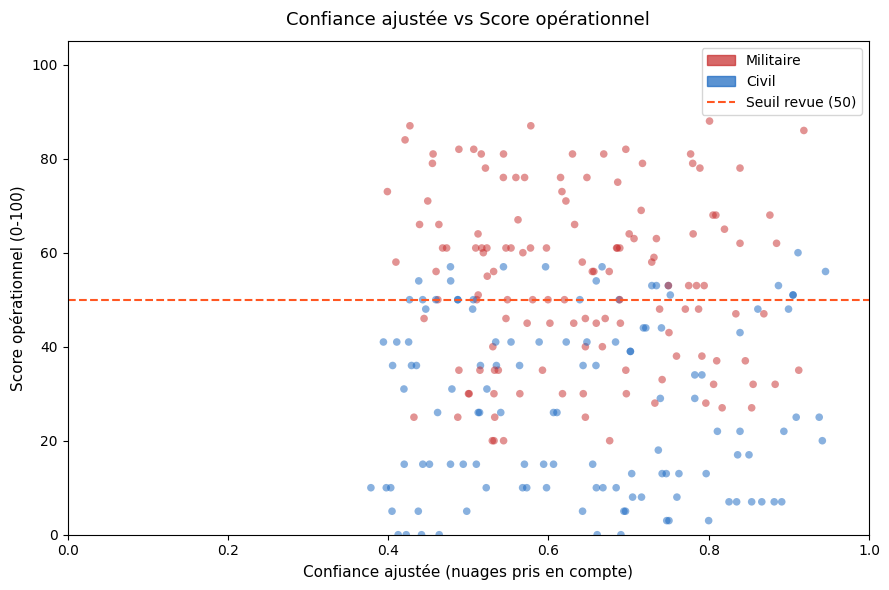

In [ ]:
# ── Graphique 3 : Scatter adjusted_confidence × priority_score ────────
fig, ax = plt.subplots(figsize=(9, 6))

couleurs_pts = scored['is_military'].map({True: '#C62828', False: '#1565C0'})

sc = ax.scatter(
    scored['adjusted_confidence'],
    scored['priority_score'],
    c=couleurs_pts,
    alpha=0.5,
    s=30,
    edgecolors='none'
)

ax.axhline(y=INTERVENTION_THRESHOLD, color='#FF5722', linestyle='--', linewidth=1.5,
           label=f'Seuil de revue humaine ({INTERVENTION_THRESHOLD})')

patch_mil = mpatches.Patch(color='#C62828', alpha=0.7, label='Militaire')
patch_civ = mpatches.Patch(color='#1565C0', alpha=0.7, label='Civil')
ax.legend(handles=[patch_mil, patch_civ,
                   plt.Line2D([0],[0], color='#FF5722', lw=1.5, linestyle='--',
                              label=f'Seuil revue ({INTERVENTION_THRESHOLD})')],
          fontsize=10)

ax.set_title('Confiance ajustée vs Score opérationnel', fontsize=13, pad=12)
ax.set_xlabel('Confiance ajustée (nuages pris en compte)', fontsize=11)
ax.set_ylabel('Score opérationnel (0-100)', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()


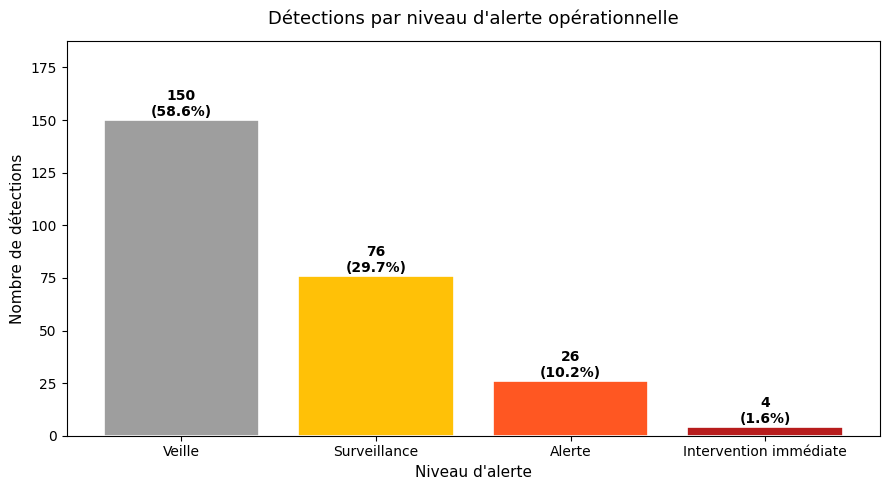

In [ ]:
# ── Graphique 4 : Bar chart détections par niveau d'alerte ───────────
# (version enrichie avec pourcentages)
fig, ax = plt.subplots(figsize=(9, 5))
niveaux = ['Veille', 'Surveillance', 'Alerte', 'Intervention immédiate']
comptes = [scored[scored['alert_level'] == n].shape[0] for n in niveaux]
total   = sum(comptes)
barres  = ax.bar(niveaux, comptes, color=[COULEURS_ALERTE[n] for n in niveaux], edgecolor='white', linewidth=1.2)

for barre, val in zip(barres, comptes):
    pct = val / total * 100
    ax.text(barre.get_x() + barre.get_width() / 2, barre.get_height() + 0.5,
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Détections par niveau d\'alerte opérationnelle', fontsize=13, pad=12)
ax.set_xlabel('Niveau d\'alerte', fontsize=11)
ax.set_ylabel('Nombre de détections', fontsize=11)
ax.set_ylim(0, max(comptes) * 1.25)
plt.tight_layout()
plt.show()


## Section 6 — Export des résultats et résumé opérationnel

In [ ]:
# ── Export des fichiers ──────────────────────────────────────────────
import os
OUTPUT_DIR = DATA_DIR / 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Export complet
scored.to_csv(OUTPUT_DIR / 'scored_detections.csv', index=False)
print(f'Exporté : {OUTPUT_DIR / "scored_detections.csv"} ({len(scored)} lignes)')

# Export revue humaine uniquement
human_review = scored[scored['requires_human_review']].sort_values('priority_score', ascending=False)
human_review.to_csv(OUTPUT_DIR / 'human_review_required.csv', index=False)
print(f'Exporté : {OUTPUT_DIR / "human_review_required.csv"} ({len(human_review)} lignes)')


In [ ]:
# ── Résumé opérationnel final ─────────────────────────────────────────
total_det    = len(scored)
total_review = scored['requires_human_review'].sum()

# Les sous-totaux sont calculés uniquement sur les lignes en revue humaine
scored_review = scored[scored['requires_human_review'] == True]
nb_surveill   = (scored_review['alert_level'] == 'Surveillance').sum()           # score 50-69
nb_alerte     = (scored_review['alert_level'] == 'Alerte').sum()                 # score 70-84
nb_interv     = (scored_review['alert_level'] == 'Intervention immédiate').sum() # score 85-100

assert nb_surveill + nb_alerte + nb_interv == total_review, \
    f"Incohérence : {nb_surveill}+{nb_alerte}+{nb_interv} ≠ {total_review}"

nb_type_a = len(anomalie_a)
nb_type_b = len(anomalie_b)
nb_type_c = len(anomalie_c)

print('=' * 50)
print('=== RÉSUMÉ OPÉRATIONNEL ===')
print('=' * 50)
print(f'Total détections analysées                    : {total_det}')
print(f'Nécessitent une revue humaine (score ≥ 50)    : {total_review} ({total_review/total_det*100:.1f}%)')
print(f'  dont Surveillance (50-69)                   : {nb_surveill}')
print(f'  dont Alerte (70-84)                         : {nb_alerte}')
print(f'  dont Intervention immédiate (85-100)        : {nb_interv}')
print(f'Anomalies Type A (civil en zone mil active)   : {nb_type_a}')
print(f'Anomalies Type B (militaire hors zone)        : {nb_type_b}')
print(f'Anomalies Type C (classification douteuse)    : {nb_type_c}')
print('=' * 50)


=== RÉSUMÉ OPÉRATIONNEL ===
Total détections analysées                    : 256
Nécessitent une revue humaine (score ≥ 50)    : 106 (41.4%)
  dont Surveillance (50-69)                   : 76
  dont Alerte (70-84)                         : 26
  dont Intervention immédiate (85-100)        : 4
Anomalies Type A (civil en zone mil active)   : 22
Anomalies Type B (militaire hors zone)        : 63
Anomalies Type C (classification douteuse)    : 23
